# Motivational Plots

## 0. Imports & Set-Up:

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

from pathlib import Path

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import RobustScaler

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import anndata as ad
import scanpy as sc

from case_study_plotting import plot_dim_red

In [3]:
SUBSAMPLE = True
subsample_size = 0.3

In [4]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [5]:
from scipy.optimize import linear_sum_assignment


def align_cluster_labels(
    reference_labels: np.ndarray,
    labels: np.ndarray,
) -> np.ndarray:
    """
    Reorder labels to optimally match reference_labels using Hungarian assignment.
    """
    # Create common label space
    all_classes = np.union1d(reference_labels, labels)

    # Create square contingency matrix covering all class labels
    cont = np.zeros((len(all_classes), len(all_classes)), dtype=int)

    ref_to_idx = {val: i for i, val in enumerate(all_classes)}
    lab_to_idx = {val: i for i, val in enumerate(all_classes)}

    for r, l in zip(reference_labels, labels):
        cont[ref_to_idx[r], lab_to_idx[l]] += 1

    # Solve linear sum assignment
    row_ind, col_ind = linear_sum_assignment(-cont)

    # row_ind: indices in all_classes for reference
    # col_ind: indices in all_classes for predicted labels
    # Want to map: predicted class (at col_ind) -> reference class (at row_ind)
    mapping = {all_classes[c]: all_classes[r] for r, c in zip(row_ind, col_ind)}

    # Map original labels using 1-to-1 dictionary
    aligned = np.array([mapping[lbl] for lbl in labels], dtype=reference_labels.dtype)
    return aligned

In [6]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass

    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)


N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [7]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Pre-Process the Data

### 1.1 Levine:

In [8]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

ro.r(r"""
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
if (!requireNamespace("HDCytoData", quietly=TRUE)) BiocManager::install("HDCytoData")
library(HDCytoData)
library(SummarizedExperiment)
""")

ro.r("sce <- Levine_32dim_SE()")

X_all = np.array(ro.r("assay(sce)"), dtype=float)
row_df = pandas2ri.rpy2py(ro.r("as.data.frame(rowData(sce))"))
col_df = pandas2ri.rpy2py(ro.r("as.data.frame(colData(sce))"))

print(f"Full dataset: {X_all.shape[0]:,} cells x {X_all.shape[1]} markers")
print(f"Populations: {row_df['population_id'].nunique()} unique")
print(
    f"Labeled cells: {(row_df['population_id'] != 'unassigned').sum():,} / {X_all.shape[0]:,}"
)

R callback write-console: Loading required package: ExperimentHub
  
R callback write-console: Loading required package: BiocGenerics
  
R callback write-console: Loading required package: generics
  
R callback write-console: 
Attaching package: ‘generics’

  
R callback write-console: The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union

  
R callback write-console: 
Attaching package: ‘BiocGenerics’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

  
R callback write-console: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames,

Full dataset: 265,627 cells x 39 markers
Populations: 15 unique
Labeled cells: 265,627 / 265,627


In [9]:
# Filter to labeled cells only
labeled_mask = (row_df["population_id"] != "unassigned").to_numpy()
X_labeled = X_all[labeled_mask]
y_labeled = row_df["population_id"].to_numpy()[labeled_mask]

# Filter to type markers (marker_class == 2)
keep_markers = (col_df["marker_class"].astype(int) == 2).to_numpy()
X_labeled = X_labeled[:, keep_markers]
marker_names = col_df.index[keep_markers].tolist()

print(f"Labeled cells: {X_labeled.shape[0]:,} x {X_labeled.shape[1]} markers")
print(f"Populations: {len(np.unique(y_labeled))}")
print()
print("Population distribution:")
print(pd.Series(y_labeled).value_counts().to_string())

Labeled cells: 265,627 x 32 markers
Populations: 15

Population distribution:
15    161443
7      26366
10     21099
8      20108
9      16520
13      6135
2       3905
4       3295
3       2248
11      1238
1       1207
6        916
14       513
12       330
5        304


In [10]:
# Arcsinh transform (CyTOF standard) + robust scaling
cofactor = 5.0
X_transformed = np.arcsinh(X_labeled.astype(np.float64) / cofactor)
X_scaled = RobustScaler(quantile_range=(10, 90)).fit_transform(X_transformed)

In [11]:
# Remove population 15 from the labeled dataset
keep_mask = y_labeled != 15

y_labeled = y_labeled[keep_mask]
X_labeled = X_labeled[keep_mask]
X_transformed = X_transformed[keep_mask]
X_scaled = X_scaled[keep_mask]

print(
    f"After removing population 15: {X_scaled.shape[0]:,} cells x {X_scaled.shape[1]} markers"
)
print("Remaining populations:", np.unique(y_labeled))

After removing population 15: 104,184 cells x 32 markers
Remaining populations: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [12]:
y_pd_s = pd.Series(y_labeled, name="population_id")

target_n = 5000
n_samples = X_scaled.shape[0]

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=target_n,
    random_state=RANDOM_SEED,
)
_, selected_idx = next(sss.split(X_scaled, y_pd_s))

frac = len(selected_idx) / n_samples

X_scaled = X_scaled[selected_idx]
y_pd_s = y_pd_s.iloc[selected_idx].reset_index(drop=True)
y_labeled = y_pd_s.to_numpy()

print(f"Subsampled to {X_scaled.shape[0]:,} cells ({frac:.0%})")
print(
    f"Final: {X_scaled.shape[0]:,} cells x {X_scaled.shape[1]} markers, "
    f"{y_pd_s.nunique()} populations"
)

Subsampled to 5,000 cells (5%)
Final: 5,000 cells x 32 markers, 14 populations


### 1.2 Klein:

In [13]:
DATA_DIR = Path("../../data/klein")
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}


def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")

    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]

    return df  # genes × cells

read four matrices (genes × cells):

In [14]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [15]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [16]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i + 1:04d}" for i in range(df.shape[1])]
    return df


d0 = add_prefix(d0, "d0")
d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4")
d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1]
    + ["d2"] * d2.shape[1]
    + ["d4"] * d4.shape[1]
    + ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y_klein = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [17]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y_klein
adata.layers["counts"] = adata.X.copy()  # raw UMIs

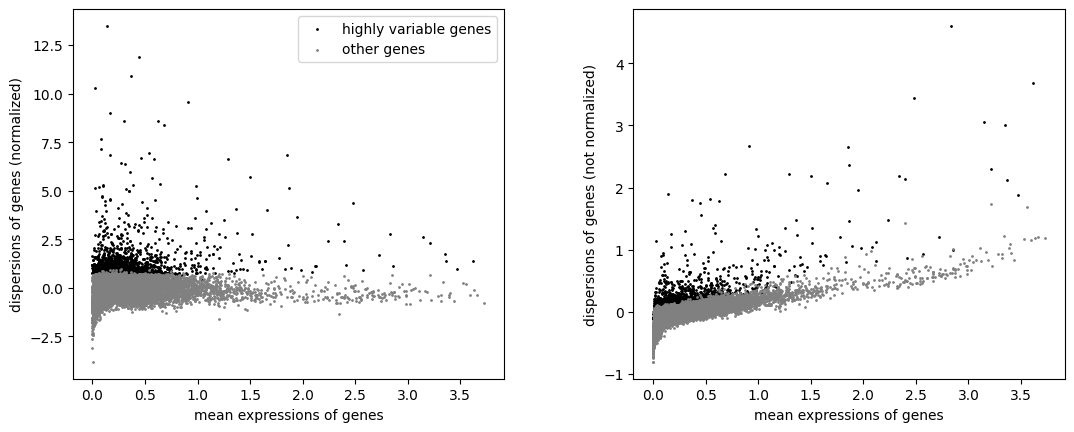

In [18]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, batch_key="condition", flavor="seurat"
)
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var["highly_variable"]].copy()

---

## 2. Parse Data:

In [19]:
X_levine = X_scaled
y_levine = y_labeled

print(f"X shape (cells × genes): {X_levine.shape[0]:,} × {X_levine.shape[1]:,}")
print(f"y shape: {y_levine.shape}")
print(f"Number of unique cell types in y: {np.unique(y_levine)}")

X shape (cells × genes): 5,000 × 32
y shape: (5000,)
Number of unique cell types in y: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [20]:
X_klein = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
X_klein = X_klein.to_numpy()
y_klein = pd.Series(adata.obs["condition"].values)

print(f"X shape (cells × genes): {X_klein.shape[0]:,} × {X_klein.shape[1]:,}")
print(f"y shape: {y_klein.shape}")
print(f"Number of unique cell types in y: {np.unique(y_klein)}")

X shape (cells × genes): 2,717 × 2,000
y shape: (2717,)
Number of unique cell types in y: ['d0' 'd2' 'd4' 'd7']


---

## 3. Motivational Plots

In [21]:
levine_clusters_6 = KMeans(n_clusters=6, random_state=RANDOM_SEED).fit_predict(X_levine)
levine_clusters_10 = KMeans(n_clusters=10, random_state=RANDOM_SEED).fit_predict(
    X_levine
)
levine_clusters_14 = KMeans(n_clusters=14, random_state=RANDOM_SEED).fit_predict(
    X_levine
)
levine_clusters_18 = KMeans(n_clusters=18, random_state=RANDOM_SEED).fit_predict(
    X_levine
)

klein_clusters_2 = KMeans(n_clusters=2, random_state=RANDOM_SEED).fit_predict(X_klein)
klein_clusters_3 = KMeans(n_clusters=3, random_state=RANDOM_SEED).fit_predict(X_klein)
klein_clusters_4 = KMeans(n_clusters=4, random_state=RANDOM_SEED).fit_predict(X_klein)
klein_clusters_5 = KMeans(n_clusters=5, random_state=RANDOM_SEED).fit_predict(X_klein)

In [22]:
levine_clusters_6 = align_cluster_labels(levine_clusters_14, levine_clusters_6)
levine_clusters_10 = align_cluster_labels(levine_clusters_14, levine_clusters_10)
levine_clusters_18 = align_cluster_labels(levine_clusters_14, levine_clusters_18)

klein_clusters_2 = align_cluster_labels(klein_clusters_4, klein_clusters_2)
klein_clusters_3 = align_cluster_labels(klein_clusters_4, klein_clusters_3)
klein_clusters_5 = align_cluster_labels(klein_clusters_4, klein_clusters_5)

saved figure to /Users/kaiwycik/GitHub/ClusteringValidation/overleaf/vis/clustering_problem.png


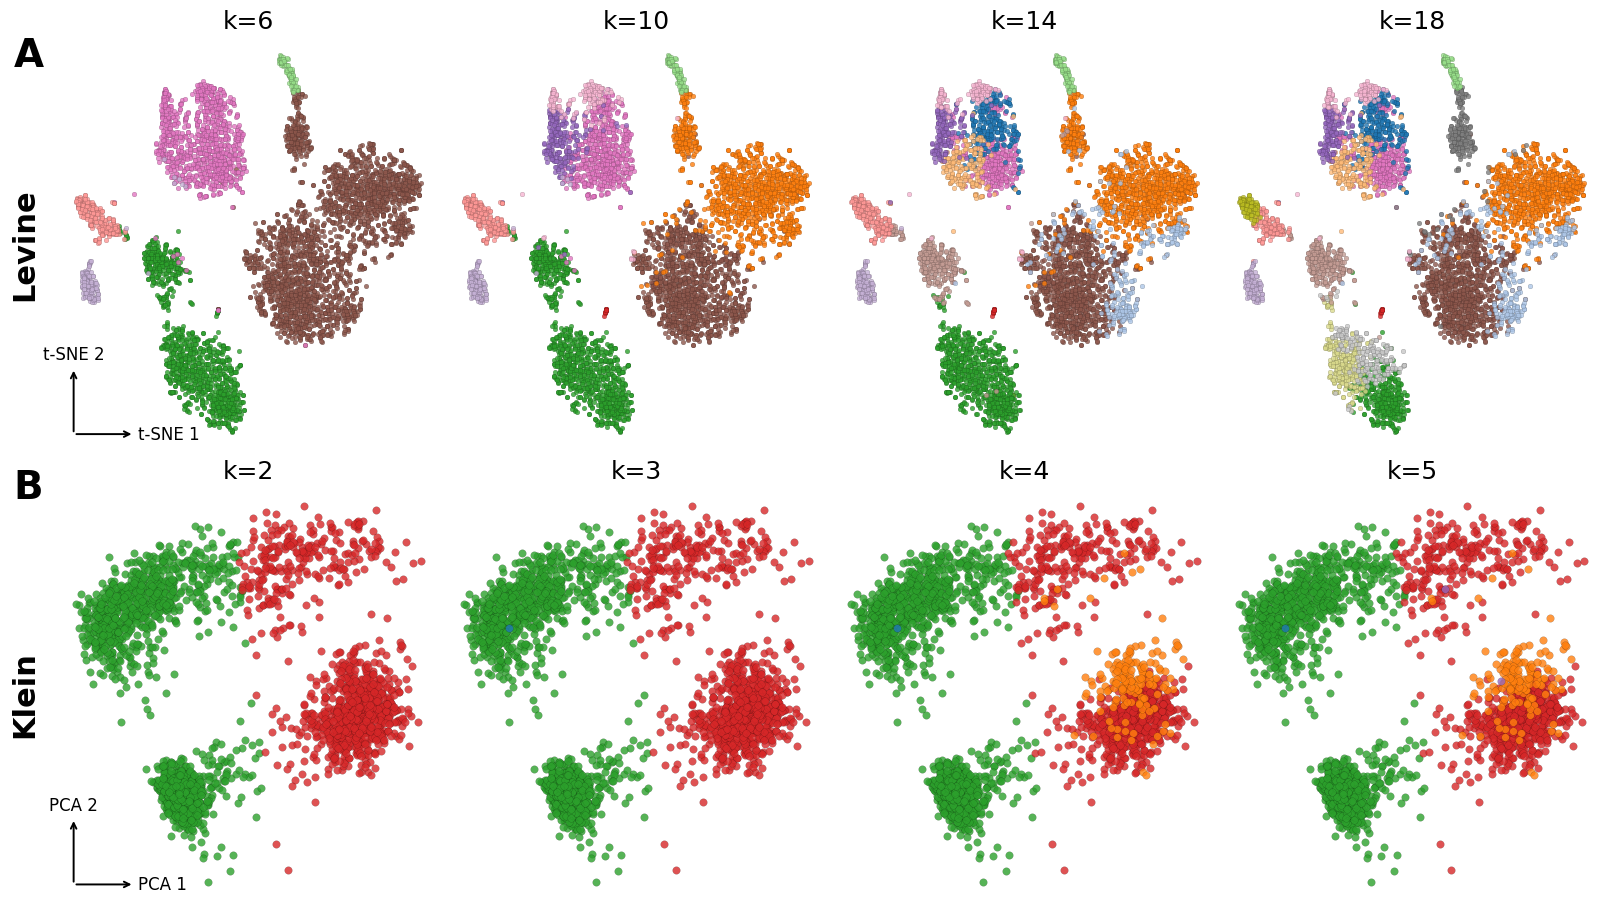

In [24]:
TITLE_FS = 18
ROW_LABEL_FS = 22
PANEL_LETTER_FS = 28
ARROW_FS = 12

fig, axes = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)
klein_palette = "tab10"

levine_panels = [
    (6, levine_clusters_6),
    (10, levine_clusters_10),
    (14, levine_clusters_14),
    (18, levine_clusters_18),
]
for j, (k, lbl) in enumerate(levine_panels):
    plot_dim_red(
        X=X_levine,
        y=lbl,
        method="tsne",
        legend_title="Cluster",
        axis_labels=('t-SNE 1', 't-SNE 2'),
        ax=axes[0, j],
        show=False,
        show_legend=False,
        show_axis_labels=False,
        axis_arrows=(j == 0),
        category_draw_order="size_desc",
        title=f"k={k}",
        title_fontsize=TITLE_FS,
        s=12,
        fontsize=ARROW_FS,
    )

klein_panels = [
    (2, klein_clusters_2),
    (3, klein_clusters_3),
    (4, klein_clusters_4),
    (5, klein_clusters_5),
]
for j, (k, lbl) in enumerate(klein_panels):
    plot_dim_red(
        X=X_klein,
        y=lbl,
        method="pca",
        legend_title="Cluster",
        axis_labels=('PCA 1', 'PCA 2'),
        ax=axes[1, j],
        show=False,
        show_legend=False,
        show_axis_labels=False,
        axis_arrows=(j == 0),
        category_draw_order="size_desc",
        title=f"k={k}",
        title_fontsize=TITLE_FS,
        s=30,
        fontsize=ARROW_FS,
        palette=klein_palette,
    )

# Row labels (dataset name) on leftmost column. plot_dim_red hides spines and
# ticks but leaves ylabel rendering intact, so we set it after the call.
axes[0, 0].set_ylabel("Levine", fontsize=ROW_LABEL_FS, fontweight="bold", labelpad=14)
axes[1, 0].set_ylabel("Klein", fontsize=ROW_LABEL_FS, fontweight="bold", labelpad=14)

# Panel letters A / B at the top-left corner of each row.
fig.text(
    0.005, 0.965, "A", fontsize=PANEL_LETTER_FS, fontweight="bold", va="top", ha="left"
)
fig.text(
    0.005, 0.485, "B", fontsize=PANEL_LETTER_FS, fontweight="bold", va="top", ha="left"
)

OUT_PATH = Path("../../../overleaf/vis/clustering_problem.png")
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"saved figure to {OUT_PATH.resolve()}")
plt.show()

---